In [1]:
# Librerías
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt


# Lab 3: PDE with FDM

## Finite-difference method (FDM) with Jacobi tolerance

Ross ANthony Miranda D'Angelo

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Fórmula de diferencias finitas

Para una malla uniforme, la ecuación de Laplace

$$
\nabla^2 u = 0
$$

se aproxima por

$$
u_{i,j} = \frac{1}{4}
\left(
u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1}
\right).
$$

En el método de **Jacobi**, todos los valores nuevos se calculan usando exclusivamente los valores de la iteración anterior.

In [2]:
def Laplace2D_Jacobi(V_ini, tol=1e-3, max_iter=100000):
    '''
    Resuelve la ecuación de Laplace 2D usando Jacobi.
    V_ini contiene las condiciones de frontera iniciales.
    tol: tolerancia sobre el cambio máximo entre iteraciones.
    '''
    V = V_ini.copy().astype(float)

    for iteration in range(1, max_iter + 1):
        V_new = V.copy()

        # Actualización de los puntos interiores
        V_new[1:-1, 1:-1] = 0.25 * (
            V[2:, 1:-1] +
            V[:-2, 1:-1] +
            V[1:-1, 2:] +
            V[1:-1, :-2]
        )

        # Error de convergencia
        error = np.max(np.abs(V_new - V))

        V = V_new

        if error < tol:
            return V, iteration, error

    print("Advertencia: no se alcanzó la tolerancia.")
    return V, iteration, error


# 1

Resolver la ecuación de Laplace en $0 \le x \le L$, $0 \le y \le L$, con

$$
u(x,0)=100\,\mathrm{V},\qquad
u(0,y)=u(L,y)=u(x,L)=0.
$$

Se pide una solución por FDM para una tolerancia entre $10^{-6}$ y $10^{-1}$, y una gráfica para $\mathrm{tol}=10^{-3}$.

In [3]:
# Parámetros
L = 100
Delta = 1
N = int(L / Delta)

tol = 1e-3

# Matriz todo a 0 V
V_ini = np.zeros((N + 1, N + 1), dtype=float)

# CdF
V_ini[:, 0] = 100.0       # y = 0
V_ini[0, :] = 0.0         # x = 0
V_ini[N, :] = 0.0         # x = L
V_ini[:, N] = 0.0         # y = L

# Jacobi
start = tm.process_time()
V1, Niter1, error1 = Laplace2D_Jacobi(V_ini, tol=tol)
end = tm.process_time()

print(f"Iteraciones = {Niter1}")
print(f"Error final = {error1:.3e}")
print(f"Tiempo de CPU = {end-start:.4f} s")


Iteraciones = 6073
Error final = 9.996e-04
Tiempo de CPU = 0.7840 s


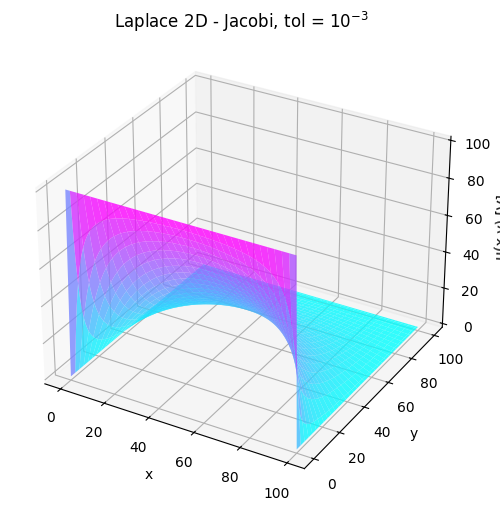

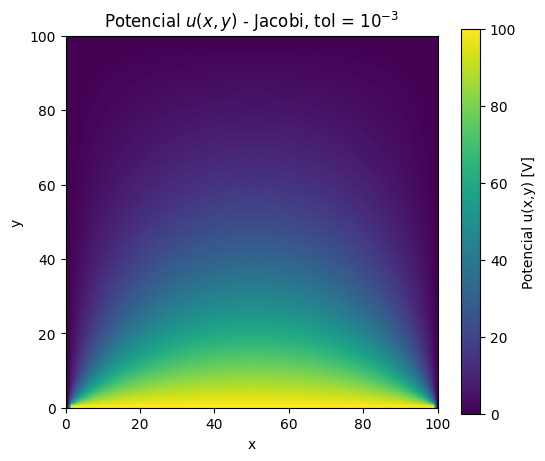

In [4]:
# gráfica del potencial
x = np.arange(N + 1) * Delta
y = np.arange(N + 1) * Delta
X, Y = np.meshgrid(x, y, indexing='ij')

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, V1, cmap='cool', alpha=0.8)

ax.set_title(r"Laplace 2D - Jacobi, tol = $10^{-3}$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y) [V]")
plt.show()

# V 2D
plt.figure(figsize=(6, 5))
plt.imshow(
    V1.T,
    origin='lower',
    extent=[0, L, 0, L],
    interpolation='bilinear',
    aspect='equal'
)
plt.colorbar(label='Potencial u(x,y) [V]')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r"Potencial $u(x,y)$ - Jacobi, tol = $10^{-3}$")
plt.show()


### Comparación con la serie de Fourier

Para esta condición de frontera, la solución puede escribirse como

$$
u(x,y)=\sum_{n=1,3,5,\ldots}^{\infty}
\frac{400}{n\pi}
\sin\left(\frac{n\pi x}{L}\right)
\frac{\sinh\left[\frac{n\pi(L-y)}{L}\right]}
{\sinh(n\pi)}.
$$

Solo aparecen armónicos impares. Para responder cuántos términos hacen falta para una tolerancia de $10^{-4}$, se compara una suma truncada con la suma anterior y se detiene cuando el cambio máximo entre ambas es menor que la tolerancia.

In [5]:
def Fourier_Laplace_constant(X, Y, L, V0, n_max):
    '''
    Serie de Fourier para u(x,0)=V0 y u=0 en las otras fronteras.
    n_max es el mayor armónico impar incluido.
    '''
    U = np.zeros_like(X, dtype=float)

    for n in range(1, n_max + 1, 2):
        a = n * np.pi

        # Forma estable para el cociente de senos hiperbólicos
        b = a * (L - Y) / L
        sinh_ratio = (
            np.exp(-a * Y / L)
            * (-np.expm1(-2 * b))
            / (-np.expm1(-2 * a))
        )

        U += (4 * V0 / (n * np.pi)) * np.sin(n * np.pi * X / L) * sinh_ratio

    return U


tol_fourier = 1e-4
U_previous = Fourier_Laplace_constant(X, Y, L, 100, 1)

n_fourier = None
fourier_error = None

# Se excluyen las fronteras para evitar que la discontinuidad de las esquinas
# domine el criterio de convergencia.
for n in range(3, 10001, 2):
    U_current = Fourier_Laplace_constant(X, Y, L, 100, n)

    fourier_error = np.max(
        np.abs(U_current[1:-1, 1:-1] - U_previous[1:-1, 1:-1])
    )

    if fourier_error < tol_fourier:
        n_fourier = n
        break

    U_previous = U_current

if n_fourier is not None:
    number_of_terms = (n_fourier + 1) // 2
    print(f"Mayor armónico incluido: n = {n_fourier}")
    print(f"Número de términos impares: {number_of_terms}")
    print(f"Cambio máximo = {fourier_error:.3e}")
else:
    print("No se alcanzó la tolerancia con el límite establecido.")


Mayor armónico incluido: n = 271
Número de términos impares: 136
Cambio máximo = 9.429e-05


#  2 (bonus)

Se tiene

$$
u(x,0)=u_0\sin\left(\frac{2\pi x}{L}\right),
$$

y $u(0,y)=u(L,y)=0$, con $u(x,y)\to0$ cuando $y\to\infty$.

Por separación de variables, el resultado analítico es

$$
\boxed{
u(x,y)=u_0\sin\left(\frac{2\pi x}{L}\right)
e^{-2\pi y/L}
}
$$

En la solución numérica se aproxima el infinito mediante una frontera superior suficientemente alejada, aquí $y=L=100$, siguiendo los valores indicados en el laboratorio.

In [6]:
# Parámetros
L2 = 100
Delta2 = 1
N2 = int(L2 / Delta2)
u0 = 100.0

# Matriz
V2_ini = np.zeros((N2 + 1, N2 + 1), dtype=float)

# Frontera inferior: f(x)
x2 = np.arange(N2 + 1) * Delta2
y2 = np.arange(N2 + 1) * Delta2

V2_ini[:, 0] = u0 * np.sin(2 * np.pi * x2 / L2)

# Laterales y frontera superior = 0 V
V2_ini[0, :] = 0.0
V2_ini[N2, :] = 0.0
V2_ini[:, N2] = 0.0

start = tm.process_time()
V2, Niter2, error2 = Laplace2D_Jacobi(V2_ini, tol=1e-6)
end = tm.process_time()

print(f"Iteraciones = {Niter2}")
print(f"Error final = {error2:.3e}")
print(f"Tiempo de CPU = {end-start:.4f} s")


Iteraciones = 7830
Error final = 9.999e-07
Tiempo de CPU = 0.6148 s


Error máximo absoluto = 1.867e-01
Error medio absoluto  = 1.996e-02


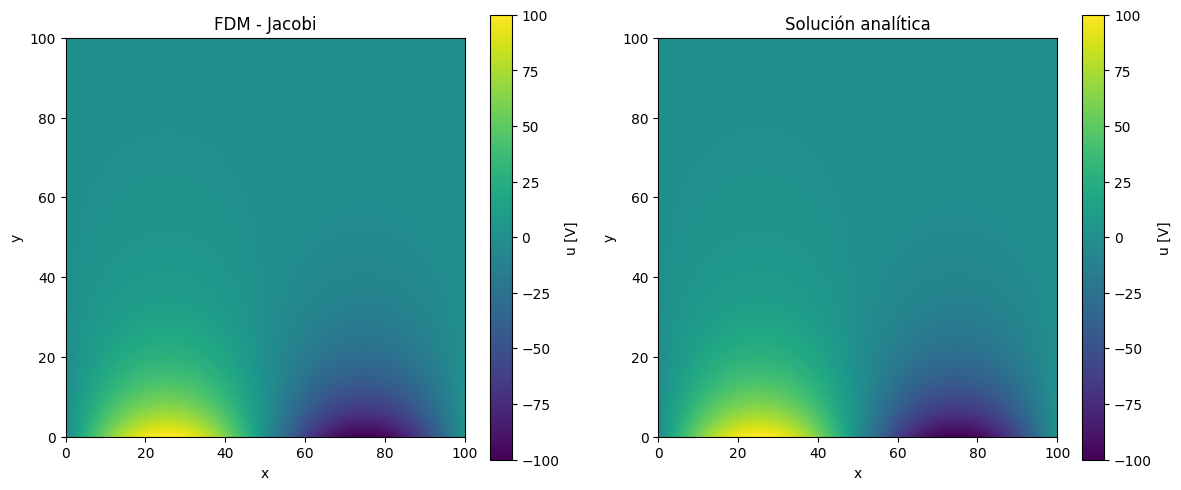

In [7]:
# Solución analítica
X2, Y2 = np.meshgrid(x2, y2, indexing='ij')

U2_exact = u0 * np.sin(2 * np.pi * X2 / L2) * np.exp(-2 * np.pi * Y2 / L2)

# Error numérico respecto a la solución analítica
error_abs = np.abs(V2 - U2_exact)

print(f"Error máximo absoluto = {np.max(error_abs):.3e}")
print(f"Error medio absoluto  = {np.mean(error_abs):.3e}")

# Comparación visual
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax[0].imshow(
    V2.T, origin='lower', extent=[0, L2, 0, L2],
    interpolation='bilinear', aspect='equal'
)
ax[0].set_title("FDM - Jacobi")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(im1, ax=ax[0], label='u [V]')

im2 = ax[1].imshow(
    U2_exact.T, origin='lower', extent=[0, L2, 0, L2],
    interpolation='bilinear', aspect='equal'
)
ax[1].set_title("Solución analítica")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
fig.colorbar(im2, ax=ax[1], label='u [V]')

plt.tight_layout()
plt.show()


## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3**

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

# 3

Se resuelve $\nabla^2\phi=0$ alrededor de dos placas rectangulares.

Para hacer explícita la geometría en la malla se usan los valores del notebook de referencia:

- separación entre placas: $d=10$ unidades,
- longitud de las placas: $\ell=20$ unidades,
- potencial: $+50$ V y $-50$ V,
- dominio computacional: $100\times100$ puntos.

Las placas se mantienen fijas durante las iteraciones y los bordes externos del dominio se toman a $0$ V. Esto representa una aproximación numérica de la región exterior al capacitor.

In [8]:
def capacitor_df(Nx=100, Ny=100, d=10, l=20, volt=50, tol=1e-5, max_iter=100000):
    '''
    Potencial de un capacitor de dos placas rectangulares usando Jacobi.

    d    : separación entre placas
    l    : longitud vertical de cada placa
    volt : magnitud del potencial de cada placa (+volt y -volt)
    '''
    V = np.zeros((Nx, Ny), dtype=float)

    # Centro del dominio
    xc = Nx // 2
    yc = Ny // 2

    # Placas verticales de un espesor de una celda
    x_left = int(xc - d / 2)
    x_right = int(xc + d / 2)

    y_bottom = int(yc - l / 2)
    y_top = int(yc + l / 2)

    left_plate = (x_left, slice(y_bottom, y_top + 1))
    right_plate = (x_right, slice(y_bottom, y_top + 1))

    # Condiciones iniciales de las placas
    V[left_plate] = +volt
    V[right_plate] = -volt

    for iteration in range(1, max_iter + 1):
        V_new = V.copy()

        # Laplace en los puntos interiores
        V_new[1:-1, 1:-1] = 0.25 * (
            V[2:, 1:-1] +
            V[:-2, 1:-1] +
            V[1:-1, 2:] +
            V[1:-1, :-2]
        )

        # Bordes externos del dominio
        V_new[0, :] = 0
        V_new[-1, :] = 0
        V_new[:, 0] = 0
        V_new[:, -1] = 0

        # Volver a imponer las placas
        V_new[left_plate] = +volt
        V_new[right_plate] = -volt

        error = np.max(np.abs(V_new - V))
        V = V_new

        if error < tol:
            break

    return V, iteration, error


Nx = 100
Ny = 100
d = 10
l = 20
volt = 50

start = tm.process_time()
Vcap, Niter_cap, error_cap = capacitor_df(
    Nx=Nx, Ny=Ny, d=d, l=l, volt=volt, tol=1e-5
)
end = tm.process_time()

print(f"Iteraciones = {Niter_cap}")
print(f"Error final = {error_cap:.3e}")
print(f"Tiempo de CPU = {end-start:.4f} s")


Iteraciones = 5726
Error final = 9.993e-06
Tiempo de CPU = 0.7770 s


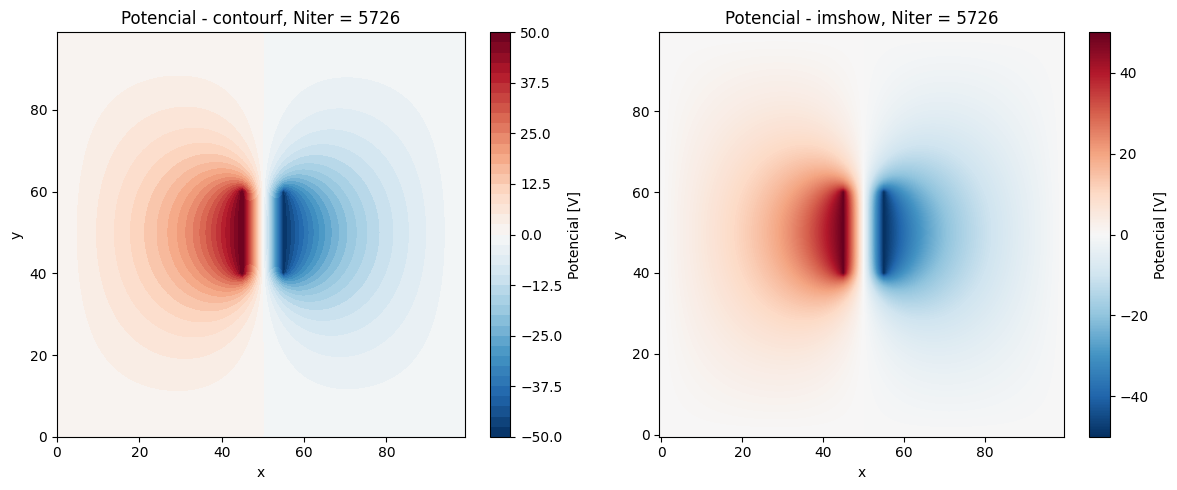

In [9]:
# Potencial: contourf e imshow
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
cf = ax1.contourf(Vcap.T, levels=40, cmap='RdBu_r')
ax1.set_title(f"Potencial - contourf, Niter = {Niter_cap}")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(cf, ax=ax1, label='Potencial [V]')

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(
    Vcap.T, origin='lower', interpolation='bilinear',
    cmap='RdBu_r', aspect='equal'
)
ax2.set_title(f"Potencial - imshow, Niter = {Niter_cap}")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
fig.colorbar(im, ax=ax2, label='Potencial [V]')

plt.tight_layout()
plt.show()


## Campo eléctrico

Uso

$$
\vec E=-\nabla\phi,
$$

por lo que, con diferencias centrales,

$$
E_x\approx-\frac{\phi_{i+1,j}-\phi_{i-1,j}}{2\Delta},
\qquad
E_y\approx-\frac{\phi_{i,j+1}-\phi_{i,j-1}}{2\Delta}.
$$

Finalmente se visualiza el campo mediante líneas de flujo sobre el mapa de potencial.

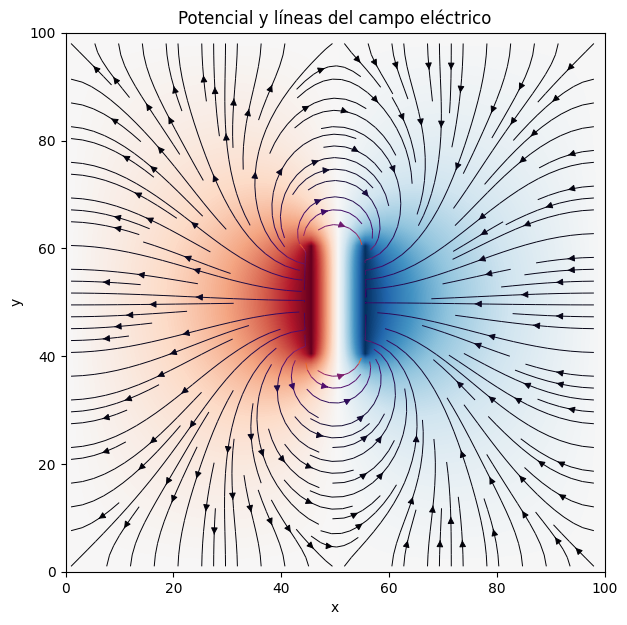

|E| máximo = 13.250 V/unidad


In [10]:
# Campo eléctrico mediante diferencias centrales
Delta_cap = 1.0
U = Vcap.copy()

Ex = -(U[2:, 1:-1] - U[:-2, 1:-1]) / (2 * Delta_cap)
Ey = -(U[1:-1, 2:] - U[1:-1, :-2]) / (2 * Delta_cap)

# Coordenadas correspondientes al campo interior
xE = np.arange(1, Nx - 1) * Delta_cap
yE = np.arange(1, Ny - 1) * Delta_cap
XE, YE = np.meshgrid(xE, yE, indexing='ij')

magnitude = np.sqrt(Ex**2 + Ey**2)

fig, ax = plt.subplots(figsize=(8, 7))

# Fondo: potencial
ax.imshow(
    U.T,
    origin='lower',
    cmap='RdBu_r',
    extent=[0, Nx, 0, Ny],
    interpolation='bilinear',
    aspect='equal'
)

# Líneas de campo
ax.streamplot(
    XE.T, YE.T,
    Ex.T, Ey.T,
    color=magnitude.T,
    cmap='inferno',
    density=1.5,
    linewidth=0.7
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Potencial y líneas del campo eléctrico')
plt.show()

print(f"|E| máximo = {np.max(magnitude):.3f} V/unidad")




> **Nota:** en el notebook de referencia, la rutina `Laplace2D_FDM` actualiza la misma matriz durante el barrido. Eso corresponde al esquema de Gauss-Seidel, aunque el texto lo presenta dentro de la discusión de Jacobi. Para este laboratorio implemente Jacobi de forma estricta, usando una matriz nueva en cada iteración.